In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df=pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv",header=1)

In [19]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [20]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [22]:
df.loc[:122,'Region']=0
df.loc[122:,'Region']=1

In [23]:
df['Region'].value_counts()

Region
1.0    124
0.0    122
Name: count, dtype: int64

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       246 non-null    float64
dtypes: float64(1), object(14)
memory usage: 29.0+ KB


In [25]:
df=df.dropna().reset_index(drop=True)

In [26]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [27]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1.0


In [28]:
df=df.drop(122).reset_index(drop=True)

In [29]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [30]:
df[['day', 'month', 'year', 'Temperature', ' RH', ' Ws']]=df[['day', 'month', 'year', 'Temperature', ' RH', ' Ws']].astype(int)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4    RH          243 non-null    int64  
 5    Ws          243 non-null    int64  
 6   Rain         243 non-null    object 
 7   FFMC         243 non-null    object 
 8   DMC          243 non-null    object 
 9   DC           243 non-null    object 
 10  ISI          243 non-null    object 
 11  BUI          243 non-null    object 
 12  FWI          243 non-null    object 
 13  Classes      243 non-null    object 
 14  Region       243 non-null    float64
dtypes: float64(1), int64(6), object(8)
memory usage: 28.6+ KB


In [32]:
df.columns=df.columns.str.strip()

In [33]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [34]:
obj=[features for features in df.columns if df[features].dtypes=='O']


In [35]:
obj

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [36]:
for i in obj:
  if(i!='Classes'):
    df[i]=df[i].astype(float)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    float64
dtypes: float64(8), int64(6), object(1)
memory usage: 28.6+ KB


In [98]:
df.to_csv('Algerian_forest_fires_cleaned_dataset_UPDATE.csv',index=False)

In [38]:
df1=pd.read_csv("Algerian_forest_fires_cleaned_dataset_UPDATE.csv")

In [39]:
df2=df1.drop(columns=['day','month','year'])

In [40]:
df2.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0.0


In [41]:
df2['Classes']=np.where(df2['Classes'].str.contains('not fire'),0,1)

In [42]:
df2.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0.0


In [43]:
df2['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

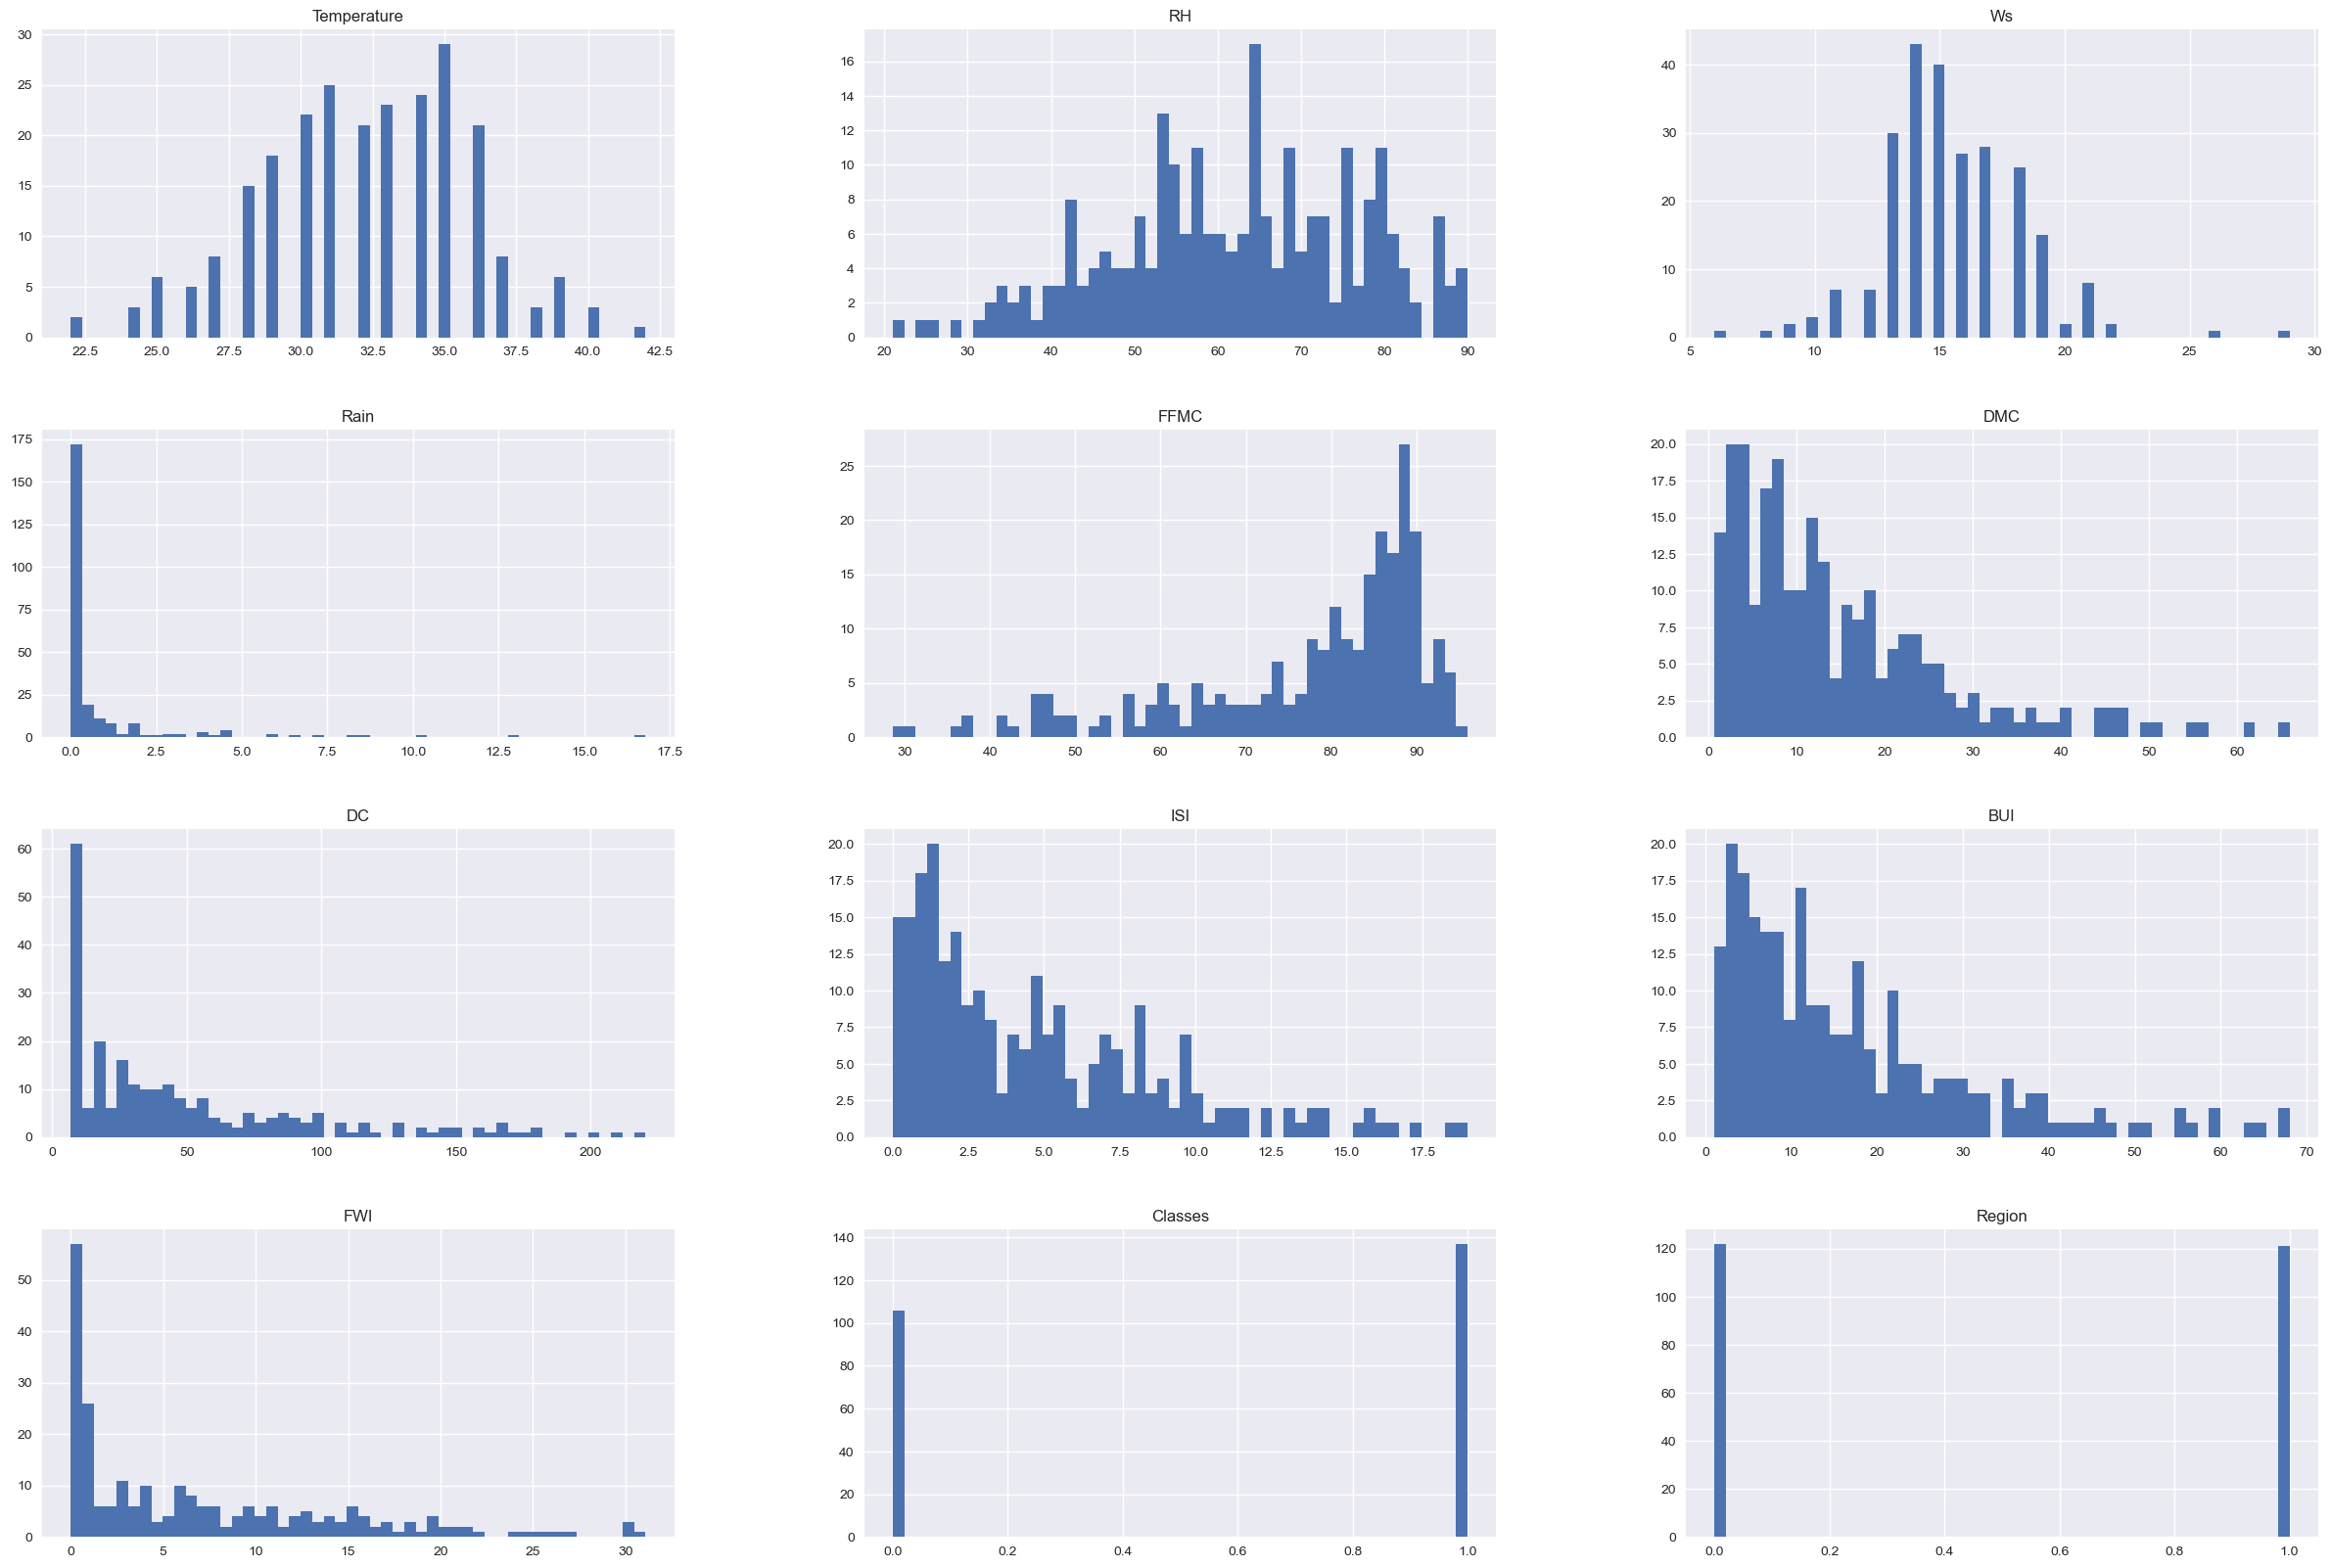

In [44]:
import seaborn as sns
plt.style.use('seaborn-v0_8')
df2.hist(bins=50,figsize=(30,20))
plt.show()

In [45]:
df2.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

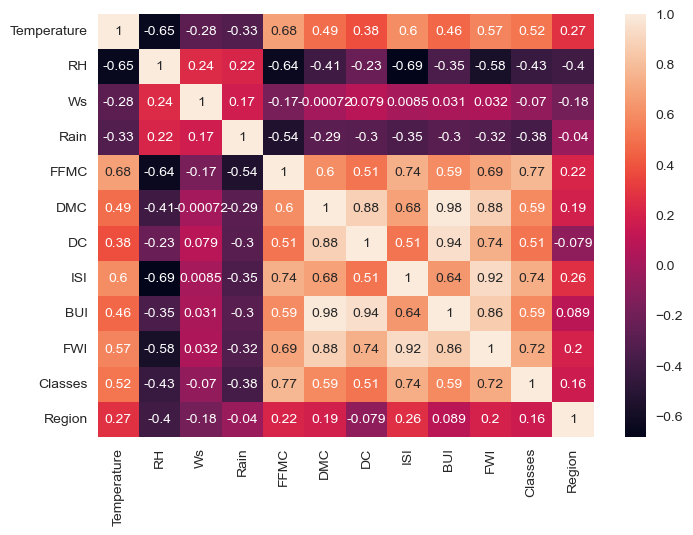

In [46]:
sns.heatmap(df2.corr(),annot=True)

In [47]:
percentage=df2['Classes'].value_counts(normalize=True)*100


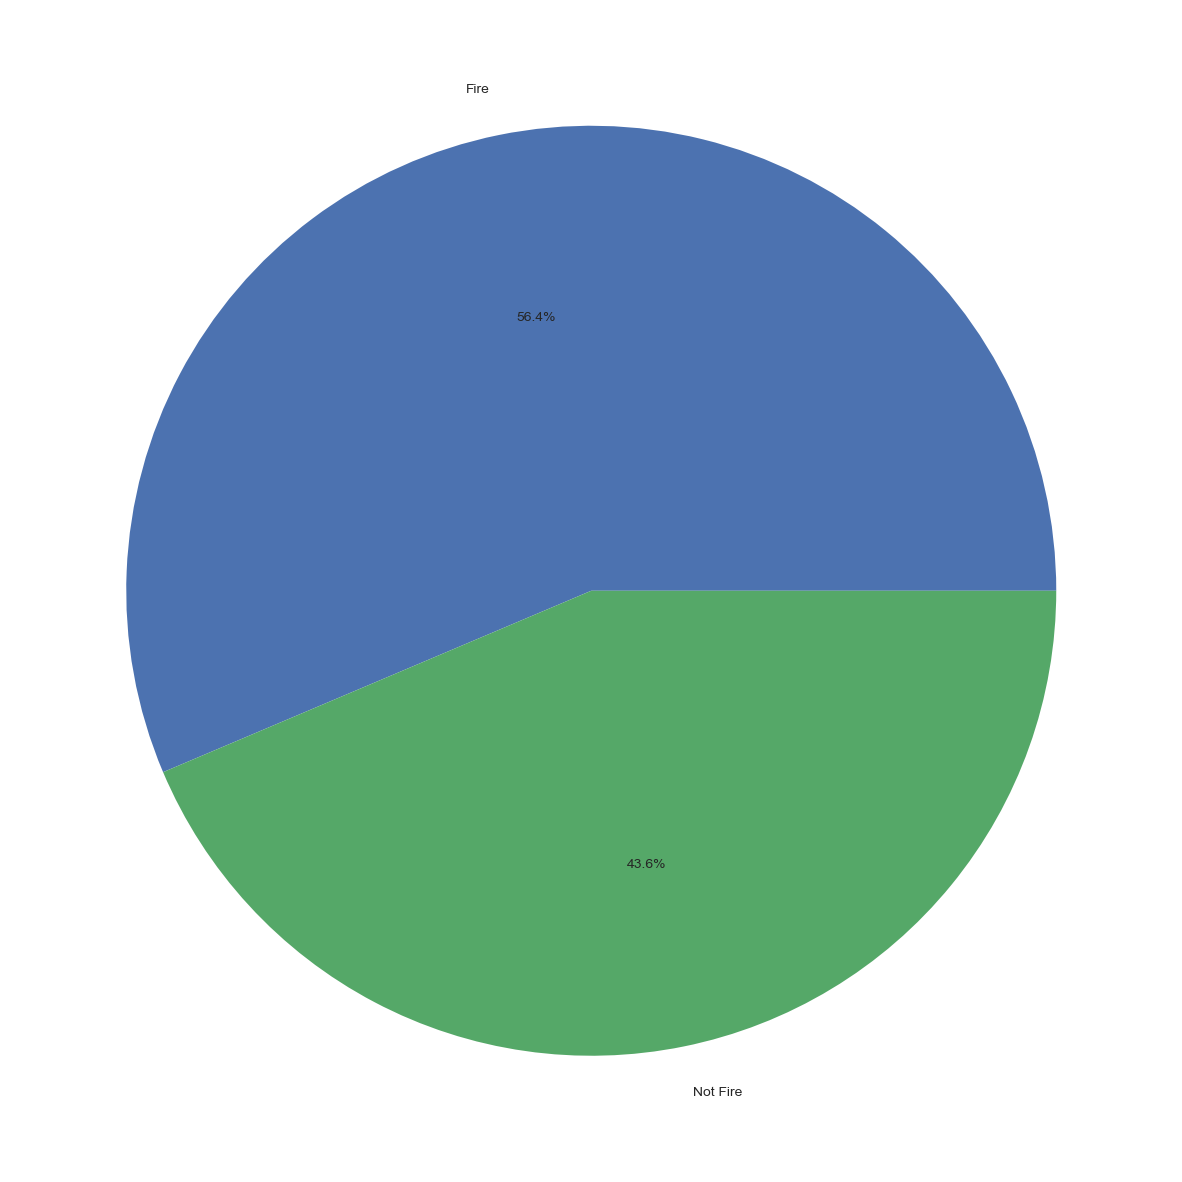

In [48]:
class_labels=["Fire","Not Fire"]
plt.figure(figsize=(15,20))
plt.pie(percentage,labels=class_labels,autopct="%1.1f%%")
plt.show()


C:\Users\saksh\AppData\Local\Temp\ipykernel_15668\2373729145.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dftemp['Classes']=np.where(dftemp['Classes'].str.contains('not fire'),'Not Fire','Fire')


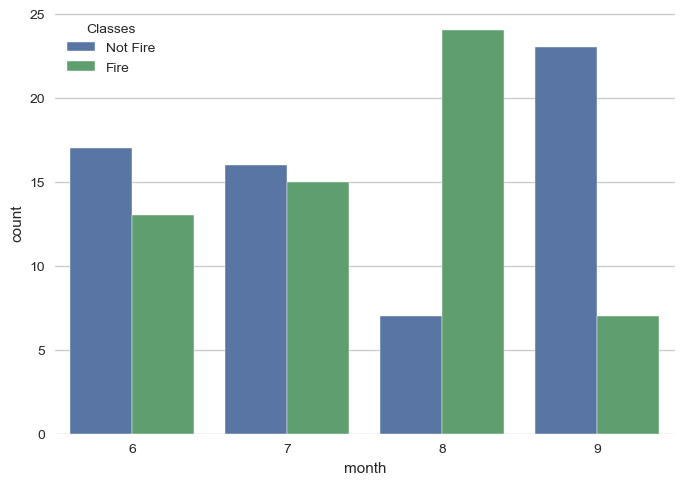

In [49]:
dftemp=df.loc[df['Region']==0]
dftemp['Classes']=np.where(dftemp['Classes'].str.contains('not fire'),'Not Fire','Fire')
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=dftemp)
plt.show()


In [50]:
dftemp.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,Not Fire,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,Not Fire,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,Not Fire,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,Not Fire,0.0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,Not Fire,0.0


C:\Users\saksh\AppData\Local\Temp\ipykernel_15668\30024398.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dftemp['Classes']=np.where(dftemp['Classes'].str.contains('not fire'),'Not Fire','Fire')


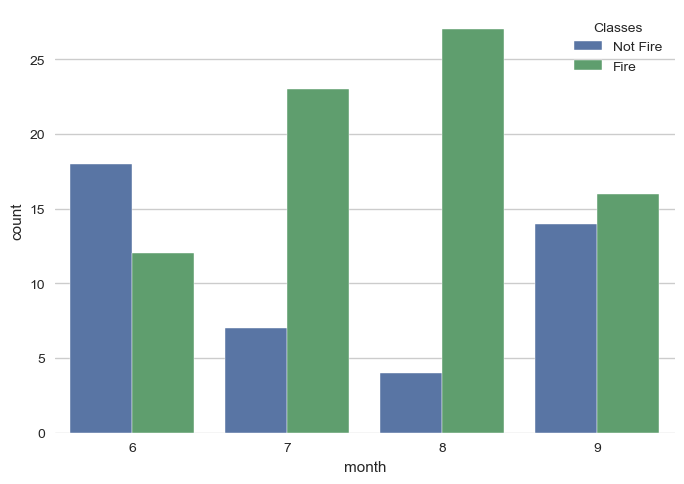

In [51]:
dftemp=df.loc[df['Region']==1]
dftemp['Classes']=np.where(dftemp['Classes'].str.contains('not fire'),'Not Fire','Fire')
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=dftemp)
plt.show()

In [52]:
df2.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0.0


In [53]:
X=df2.drop('FWI',axis=1)
y=df2[['FWI']]

In [54]:
X

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0.0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1.0
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1.0
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1.0
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1.0


In [55]:
y

,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5
...,...
238,6.5
239,0.0
240,0.2
241,0.7


<Axes: >

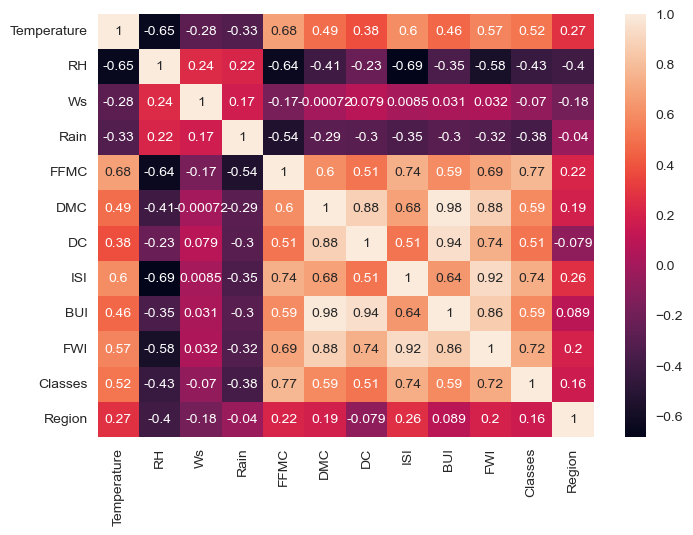

In [56]:
sns.heatmap(df2.corr(),annot=True)

In [57]:
def correlation(dataset,threshold):
    corr_colname=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if(corr_matrix.iloc[i,j]>threshold):
                corr_feature=corr_matrix.columns[i]
                corr_colname.add(corr_feature)
    return corr_colname

In [58]:
features=correlation(X,0.85)

In [59]:
features

{'BUI', 'DC'}

In [60]:
X.drop(features,axis=1,inplace=True)

In [61]:
X

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
0,29,57,18,0.0,65.7,3.4,1.3,0,0.0
1,29,61,13,1.3,64.4,4.1,1.0,0,0.0
2,26,82,22,13.1,47.1,2.5,0.3,0,0.0
3,25,89,13,2.5,28.6,1.3,0.0,0,0.0
4,27,77,16,0.0,64.8,3.0,1.2,0,0.0
...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,4.5,1,1.0
239,28,87,15,4.4,41.1,6.5,0.1,0,1.0
240,27,87,29,0.5,45.9,3.5,0.4,0,1.0
241,24,54,18,0.1,79.7,4.3,1.7,0,1.0


In [62]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [63]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((194, 9), (49, 9), (194, 1), (49, 1))

In [64]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_cleaned=scaler.fit_transform(X_train)
X_test_cleaned=scaler.transform(X_test)

In [65]:
X_train_cleaned.shape

(194, 9)

In [66]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [67]:
regression.fit(X_train_cleaned,y_train)

LinearRegression()

In [68]:
y_pred=regression.predict(X_test_cleaned)

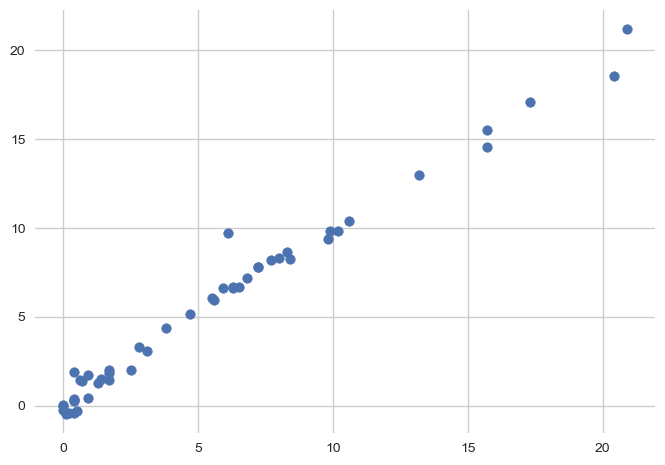

In [69]:
plt.scatter(y_test,y_pred)

In [70]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)

In [71]:
print('MAE:',mae)
print('MSE:',mae)
print('RMSE:',rmse)

MAE: 0.5049978694165654
MSE: 0.5049978694165654
RMSE: 0.7670065260940511


In [72]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print('R2:',score)

R2: 0.9805895859259883


In [73]:
1-((1-(score*score))*(len(y_test)-1))/(len(y_test)-X_train.shape[1]-1)

0.9526842289556938

Text(0.5, 1.0, 'X_train after scaling')

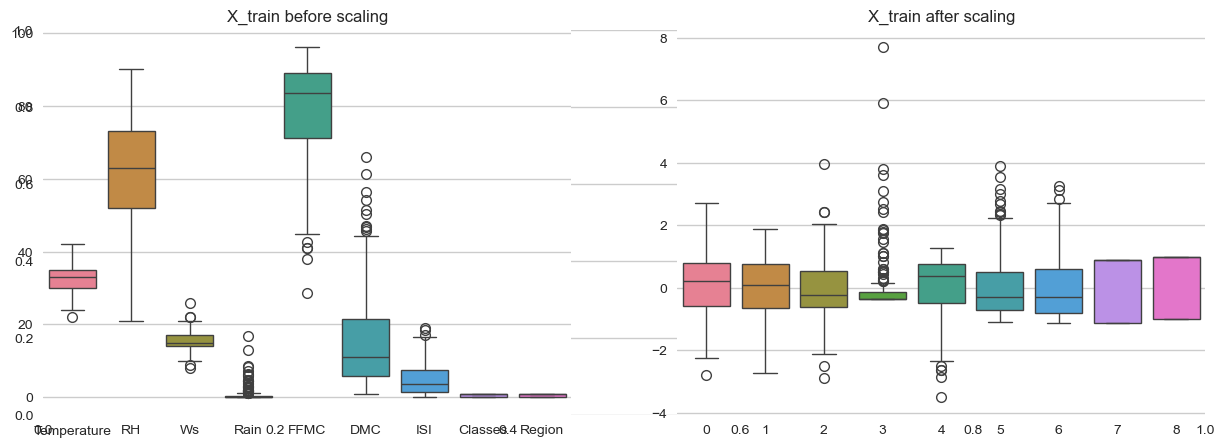

In [74]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train before scaling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_cleaned)
plt.title('X_train after scaling')

In [75]:
from sklearn.linear_model import Lasso
lasso=Lasso()
lasso.fit(X_train_cleaned,y_train)
y_pred=lasso.predict(X_test_cleaned)
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
print('MAE:',mae)
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print('R2:',score)

MAE: 1.0093958923873405
R2: 0.9430507350726564


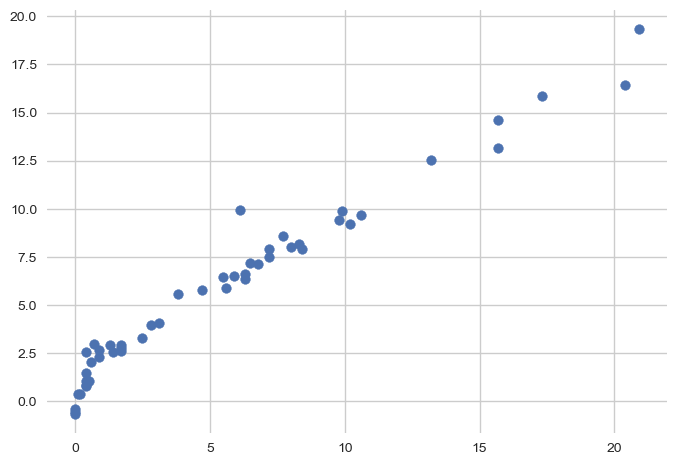

In [76]:
plt.scatter(y_test,y_pred)

MAE: 0.519204832584481
R2: 0.9801058063273599


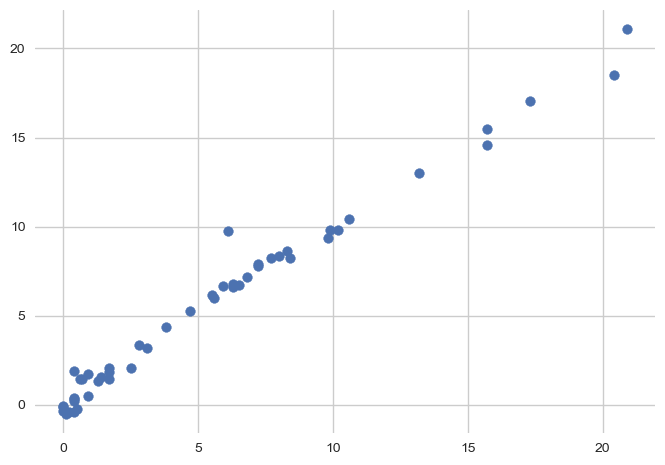

In [77]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_train_cleaned,y_train)
y_pred=ridge.predict(X_test_cleaned)
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
print('MAE:',mae)
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print('R2:',score)
plt.scatter(y_test,y_pred)

MAE: 0.6869262008277159
R2: 0.9722193780965623


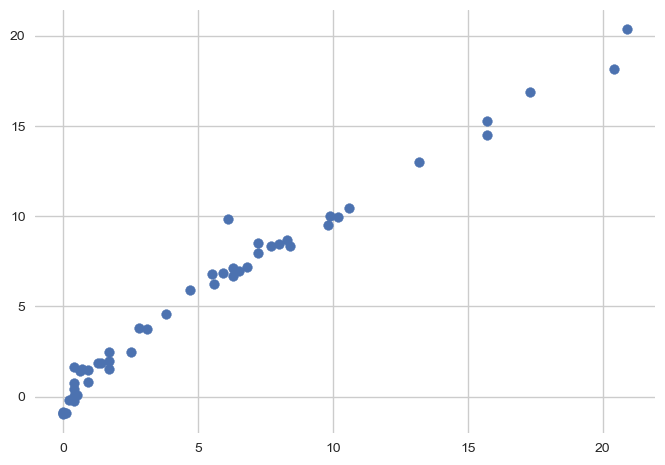

In [78]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_cleaned,y_train)
y_pred=ridgecv.predict(X_test_cleaned)
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
print('MAE:',mae)
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print('R2:',score)
plt.scatter(y_test,y_pred)

In [79]:
ridgecv.best_score_

np.float64(0.9551929675974657)

MAE: 0.555671503161787
R2: 0.978328234520343


C:\Users\saksh\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


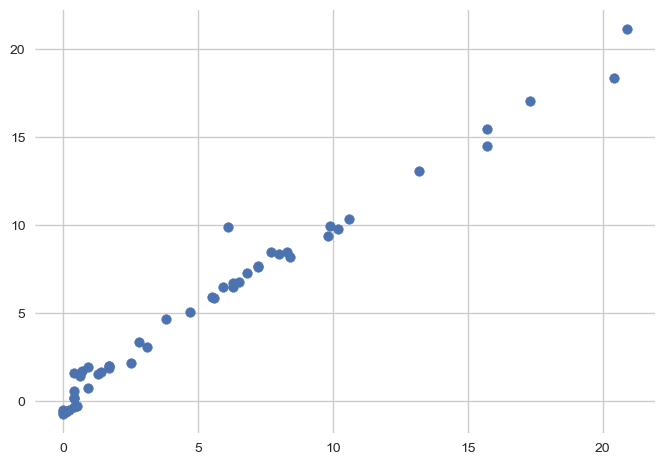

In [80]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_cleaned,y_train)
y_pred=lassocv.predict(X_test_cleaned)
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
print('MAE:',mae)
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print('R2:',score)
plt.scatter(y_test,y_pred)

In [81]:
lassocv.alphas_

array([7.1563667 , 6.67405153, 6.2242428 , 5.80474966, 5.41352896,
       5.04867523, 4.70841142, 4.39108025, 4.09513613, 3.81913766,
       3.56174057, 3.32169117, 3.09782031, 2.88903759, 2.69432612,
       2.51273756, 2.34338746, 2.18545099, 2.0381589 , 1.90079382,
       1.77268667, 1.65321353, 1.54179247, 1.43788081, 1.34097246,
       1.2505954 , 1.16630946, 1.08770411, 1.01439649, 0.94602956,
       0.88227033, 0.82280827, 0.76735374, 0.71563667, 0.66740515,
       0.62242428, 0.58047497, 0.5413529 , 0.50486752, 0.47084114,
       0.43910802, 0.40951361, 0.38191377, 0.35617406, 0.33216912,
       0.30978203, 0.28890376, 0.26943261, 0.25127376, 0.23433875,
       0.2185451 , 0.20381589, 0.19007938, 0.17726867, 0.16532135,
       0.15417925, 0.14378808, 0.13409725, 0.12505954, 0.11663095,
       0.10877041, 0.10143965, 0.09460296, 0.08822703, 0.08228083,
       0.07673537, 0.07156367, 0.06674052, 0.06224243, 0.0580475 ,
       0.05413529, 0.05048675, 0.04708411, 0.0439108 , 0.04095

In [82]:
lassocv.mse_path_ 

array([[68.58934997, 64.28650232, 49.25415197, 79.11474083, 38.68688171],
       [63.2664675 , 58.77362304, 43.20292636, 77.07183352, 34.66910628],
       [56.87389457, 51.79652473, 37.15764773, 69.4806422 , 31.16497557],
       [51.2737596 , 45.69461734, 31.98560721, 62.80993539, 27.46286399],
       [45.36816855, 40.35928545, 27.56726322, 56.94442062, 23.75447628],
       [39.875005  , 35.69250404, 23.79907917, 50.31847875, 20.54655878],
       [35.0794232 , 31.60885664, 20.59132915, 44.35263414, 17.77349727],
       [30.89154006, 28.0342798 , 17.86626498, 39.14265375, 15.37720198],
       [27.23334321, 24.90389594, 15.55674604, 34.59116894, 13.30754905],
       [24.03652419, 22.16129069, 13.60451947, 30.61376519, 11.52101422],
       [21.24273995, 19.75730052, 11.95924131, 27.13693185,  9.97950732],
       [18.80004176, 17.64896267, 10.57738151, 24.09623192,  8.65087048],
       [16.66356323, 15.79916526,  9.42117661, 21.43679316,  7.50627555],
       [14.79422393, 14.17520895,  8.4

In [83]:
from sklearn.linear_model import ElasticNet
elastic=ElasticNet()
elastic.fit(X_train_cleaned,y_train)
y_pred=elastic.predict(X_test_cleaned)
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
print('MAE:',mae)
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print('R2:',score)

MAE: 1.6834416340136709
R2: 0.8676961352267807


In [84]:
elastic.alpha

1.0

MAE: 0.5710147088777219
R2: 0.9781014571778188


C:\Users\saksh\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


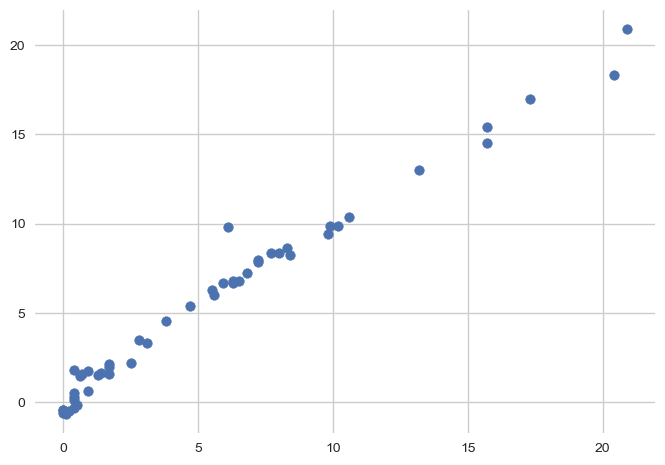

In [85]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_cleaned,y_train)
y_pred=elasticcv.predict(X_test_cleaned)
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
print('MAE:',mae)
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print('R2:',score)
plt.scatter(y_test,y_pred)

In [86]:
elasticcv.n_alphas

100

In [87]:
ridge

Ridge()

In [88]:
scaler

StandardScaler()

In [89]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))